## APhys Group Meeting (05/08/2026)

In [1]:
# imports
import ewgreaders as ewg
import ewgdatsci as dsi
import pandas as pd
import numpy as np
import xarray as xr
import scipy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from tqdm.notebook import tqdm

In [2]:
lake = 'Zug'

reader = ewg.bathy_reader.BathyReader(lake)
bathy = reader.load()
L = bathy.ysc.max().item() - bathy.ysc.min().item()

reader = ewg.meteo_reader.MeteoReader(lake, 'cham')
meteo = reader.load()

di_ctd = ewg.get_data_index(lake, 'ctd')
di_m = ewg.get_data_index(lake, 'mooring')

c:\Users\herremha\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
DLL load failed while importing _context: The specified module could not be found.
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


### Turbulent cascade

In [3]:
date = '2026-04-10'
loc = 'LZC'
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)
deploy, retrieve = mreader.get_deploy_retrieve_dates()

# inertial frequency
xsc, ysc = mreader.get_swiss_coords(oom=False)
lat, lon = dsi.utils.ch1903_to_latlng(xsc, ysc)
f = dsi.efd.coriolis_frequency(lat)
f_hz = dsi.utils.angular_frequency_to_frequency(f)

# adcp
sensor = 'adcp'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
datasets = []
for _, row in di_sel.iterrows():
    reader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = reader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    datasets.append(ds)
ds_adcp = mreader.create_adcp_chain(datasets)

# oxygen loggers
sensor = 'minidot'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
datasets = []
for _, row in di_sel.iterrows():
    reader = ewg.o2_reader.O2Reader(row.lake, row.date, row.location, row.serial_id)
    ds = reader.load()
    datasets.append(ds)
ds_do = mreader.create_instrument_chain(datasets)

# thermistors
sensor = 'rbr_temp'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
datasets = []
for _, row in di_sel.iterrows():
    reader = ewg.thermistor_reader.ThermistorReader(row.lake, row.date, row.location, row.serial_id)
    ds = reader.load()
    datasets.append(ds)
ds_temp = mreader.create_instrument_chain(datasets)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:266: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')
C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:237: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.conca

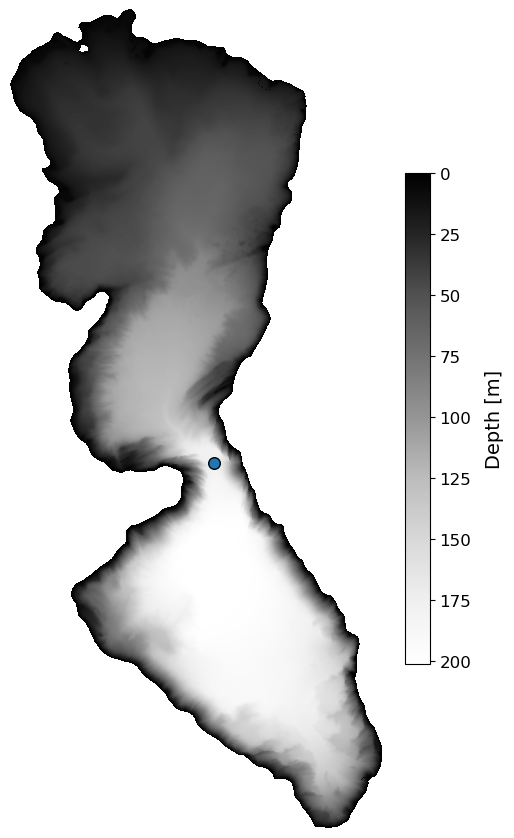

In [13]:
ratio = (bathy.ysc.max() - bathy.ysc.min()).item() / (bathy.xsc.max() - bathy.xsc.min()).item()

fig, ax = plt.subplots(figsize=(6, 6*ratio-3))

im = ax.pcolormesh(bathy['xsc'], bathy['ysc'], bathy['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.6, ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

ax.scatter(x=xsc+2e6, y=ysc+1e6, c='tab:blue', edgecolor='black', s=70)

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/aphys/2026_08_05/zug_bathy.svg', bbox_inches='tight')
plt.show()

In [4]:
# bouyancy frequency
deploy, retrieve = mreader.get_deploy_retrieve_dates()
di_sel = di_ctd[
    (di_ctd['date'].between(deploy, retrieve)) 
    & (di_ctd['profile_loc'].isin(['P6', 'VMPC']))
]

N2_data = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    reader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = reader.load()
    
    rho = ds['rho']
    depth = ds['depth']
    rho = dsi.signal.rolling_average_z(rho, 'mean', 1)
    rho = dsi.signal.order_profile(rho, False, True)
    N2 = dsi.efd.brunt_vaisala_frequency(rho)
    N2 = dsi.signal.binned_average_z(N2, 'median', 1)

    # V1H1
    ev, _, _ = dsi.lakes.vertical_modes(N2.where(N2 != 0, drop=True), 1, 'kundu')
    c = 1 / np.sqrt(ev.item())
    speriod = (2 * L) / c
    period = speriod / 3600

    dat = N2.to_dataframe().reset_index()
    dat[['date', 'time', 'V1H1_period']] = p.date, p.time, period
    N2_data.append(dat)

N2_data = pd.concat(N2_data, ignore_index=True)
N2_data['N'] = np.sqrt(N2_data['N2'])
N2_data['N_hz'] = dsi.utils.angular_frequency_to_frequency(N2_data.N)

  0%|          | 0/20 [00:00<?, ?it/s]

#### Isotherm depth

In [5]:
iso_t = dsi.lakes.isoline_t(ds_temp.temp, 5.5)
t0 = iso_t.time.values[0] + pd.Timedelta(days=1)
tf = iso_t.time.values[-1] - pd.Timedelta(days=1)

# bouyancy frequency
z_min = iso_t.min().item()
z_max = iso_t.max().item()
N_hz = N2_data[N2_data['depth'].between(z_min, z_max)]['N_hz'].mean()

# power spectrum
psd_t = dsi.signal.psd_welch(iso_t, 240)

# morlet wavelets
sfreq = 1/10
f_nyquist = sfreq / 2
freqs = np.logspace(np.log10(1e-6), np.log10(f_nyquist), 101)[:-1]
pows_t = dsi.signal.power_morlet_wavelets(iso_t, freqs, coi=True)

# low, high frequency activity
lfa_t = pows_t.sel(frequency=slice(0.2*f_hz, f_hz)).sel(time=slice(t0, tf))
hfa_t = pows_t.sel(frequency=slice(2*f_hz, N_hz)).sel(time=slice(t0, tf))
uhfa_t = pows_t.sel(frequency=slice(N_hz, 5*N_hz)).sel(time=slice(t0, tf))

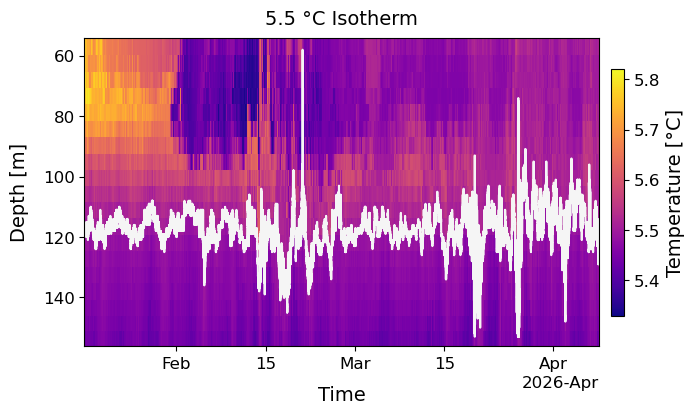

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

im = ds_temp['temp'].sel(time=slice(t0, tf)).plot(cmap='plasma', cbar_kwargs={'shrink': 0.8, 'pad': 0.02}, ax=ax, rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

sns.lineplot(x=iso_t.time, y=iso_t, color='whitesmoke', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('5.5 °C Isotherm', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()

plt.savefig('../gallery/aphys/2026_08_05/iso_t.svg', bbox_inches='tight')
plt.show()

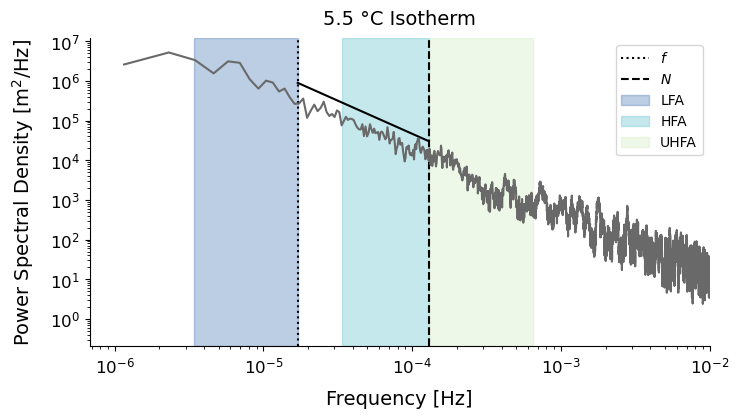

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
palette = sns.color_palette('YlGnBu_r', n_colors=3)

# power law
freqs_pl = np.logspace(np.log10(f_hz), np.log10(N_hz), 100)
y_pl = 0.01 * (freqs_pl ** (-5/3))
ax.plot(freqs_pl, y_pl, color='black', linestyle='-')

ax.axvline(f_hz, color='black', linestyle=':', label='$f$')
ax.axvline(N_hz, color='black', linestyle='--', label='$N$')
ax.axvspan(0.2*f_hz, f_hz, color=palette[0], alpha=0.3, label='LFA')
ax.axvspan(2*f_hz, N_hz, color=palette[1], alpha=0.3, label='HFA')
ax.axvspan(N_hz, 5*N_hz, color=palette[2], alpha=0.3, label='UHFA')
sns.lineplot(x=psd_t.frequency, y=psd_t, color='dimgray', ax=ax)

ax.set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
ax.set_ylabel('Power Spectral Density [m$^2$/Hz]', fontsize=14, labelpad=10)
ax.set_title('5.5 °C Isotherm', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(None, 1e-2)

plt.savefig('../gallery/aphys/2026_08_05/psd_iso_t.svg', bbox_inches='tight')
plt.show()

#### Oxic-Anoxic depth

In [7]:
iso_do = dsi.lakes.isoline_t(ds_do.do2_conc, 1)
t0 = iso_do.time.values[0] + pd.Timedelta(days=1)
tf = iso_do.time.values[-1] - pd.Timedelta(days=1)

# bouyancy frequency
z_min = iso_do.min().item()
z_max = iso_do.max().item()
N_hz = N2_data[N2_data['depth'].between(z_min, z_max)]['N_hz'].mean()

# power spectrum
psd_do = dsi.signal.psd_welch(iso_do, 240)

# morlet wavelets
sfreq = 1/60
f_nyquist = sfreq / 2
freqs = np.logspace(np.log10(1e-6), np.log10(f_nyquist), 101)[:-1]
pows_do = dsi.signal.power_morlet_wavelets(iso_do, freqs, coi=True)

# low, high frequency activity
lfa_do = pows_do.sel(frequency=slice(0.2*f_hz, f_hz)).sel(time=slice(t0, tf))
hfa_do = pows_do.sel(frequency=slice(2*f_hz, N_hz)).sel(time=slice(t0, tf))
uhfa_do = pows_do.sel(frequency=slice(N_hz, 5*N_hz)).sel(time=slice(t0, tf))

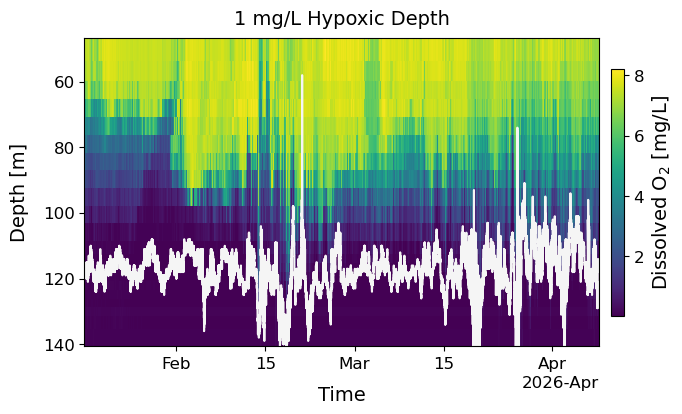

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))

im = ds_do['do2_conc'].sel(time=slice(t0, tf)).plot(cmap='viridis', cbar_kwargs={'shrink': 0.8, 'pad': 0.02, 'label': 'Dissolved O$_2$ [mg/L]'}, ax=ax, rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

sns.lineplot(x=iso_t.time, y=iso_t, color='whitesmoke', ax=ax)

ax.set_xlabel('Time', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('1 mg/L Hypoxic Depth', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)
ax.xaxis.get_offset_text().set_fontsize(12)

ax.invert_yaxis()

plt.savefig('../gallery/aphys/2026_08_05/iso_do.svg', bbox_inches='tight')
plt.show()

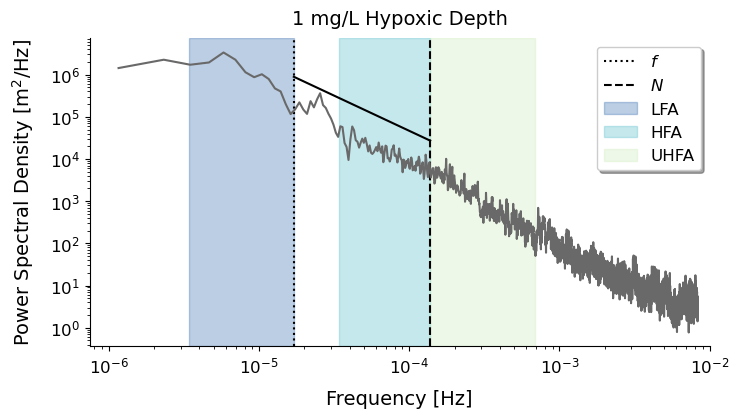

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
palette = sns.color_palette('YlGnBu_r', n_colors=3)

# power law
freqs_pl = np.logspace(np.log10(f_hz), np.log10(N_hz), 100)
y_pl = 0.01 * (freqs_pl ** (-5/3))
ax.plot(freqs_pl, y_pl, color='black', linestyle='-')

ax.axvline(f_hz, color='black', linestyle=':', label='$f$')
ax.axvline(N_hz, color='black', linestyle='--', label='$N$')
ax.axvspan(0.2*f_hz, f_hz, color=palette[0], alpha=0.3, label='LFA')
ax.axvspan(2*f_hz, N_hz, color=palette[1], alpha=0.3, label='HFA')
ax.axvspan(N_hz, 5*N_hz, color=palette[2], alpha=0.3, label='UHFA')
sns.lineplot(x=psd_do.frequency, y=psd_do, color='dimgray', ax=ax)

ax.set_xlabel('Frequency [Hz]', fontsize=14, labelpad=10)
ax.set_ylabel('Power Spectral Density [m$^2$/Hz]', fontsize=14, labelpad=10)
ax.set_title('1 mg/L Hypoxic Depth', fontsize=14, pad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(None, 1e-2)

ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper right', bbox_to_anchor=(1, 1))

plt.savefig('../gallery/aphys/2026_08_05/psd_iso_do.svg', bbox_inches='tight')
plt.show()

In [80]:
# wind speed, 1-hour rolling average
ws = meteo.sel(time=slice(t0, tf)).wind_speed
ws_ra = ws.rolling(time=6, center=True).mean()
#wind_dir = meteo.sel(time=slice(t0, tf)).wind_direction
#wind = dsi.signal.wind_projection(wind_speed, wind_dir, 110)

# velocity projection, lowpass filter
vel = dsi.signal.velocity_projection(ds_adcp.vel, angle=110)
vel_lp = dsi.signal.lowpass_filter_z(vel, f_hz)
vel_lp_avg = vel_lp.sel(depth=slice(z_min, z_max)).mean(dim='depth')

# integrate HFA
hfa_do_int = hfa_do.integrate('frequency')
uhfa_do_int = uhfa_do.integrate('frequency')

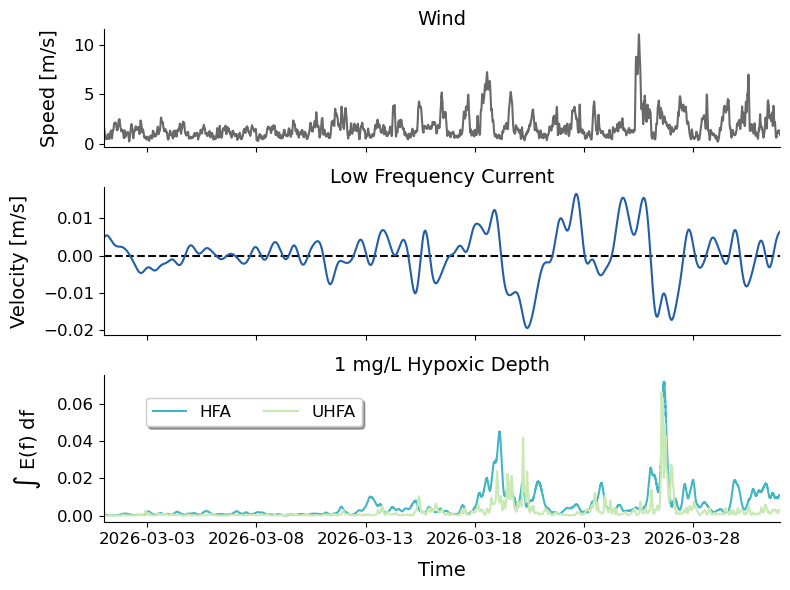

In [89]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(8, 6), sharex=True, height_ratios=[0.8, 1, 1])
t_start = '2026-03-01'
t_end = '2026-04-01'

# wind
sns.lineplot(x=ws_ra.time, y=ws_ra, color='dimgray', ax=ax[0])

# current
ax[1].axhline(0, color='black', linestyle='--')
sns.lineplot(x=vel_lp_avg.time, y=vel_lp_avg, color=palette[0], ax=ax[1])

# HFA
sns.lineplot(x=hfa_do_int.time, y=hfa_do_int, color=palette[1], ax=ax[2], label='HFA')
sns.lineplot(x=uhfa_do_int.time, y=uhfa_do_int, color=palette[2], ax=ax[2], label='UHFA')

ax[2].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Speed [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Velocity [m/s]', fontsize=14, labelpad=10)
ax[2].set_ylabel(r'$\int$ E(f) df', fontsize=14, labelpad=10)
ax[0].set_title('Wind', fontsize=14, pad=0)
ax[1].set_title('Low Frequency Current', fontsize=14, pad=0)
ax[2].set_title('1 mg/L Hypoxic Depth', fontsize=14, pad=0)
ax[2].xaxis.set_major_locator(mdates.DayLocator(interval=5))

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)

#ax[1].set_yscale('log')
ax[2].legend(fontsize=12, ncols=2, shadow=True, loc='upper left', bbox_to_anchor=(0.05, 0.9))
ax[2].set_xlim(pd.to_datetime(t_start), pd.to_datetime(t_end))

plt.tight_layout()
plt.savefig('../gallery/aphys/2026_08_05/vlp_hfaint_do.svg', bbox_inches='tight')
plt.show()

In [91]:
pows_do_z = dsi.signal.log_z_power(pows_do.sel(frequency=slice(0.2*f_hz, 5*N_hz), time=slice(t_start, t_end)))

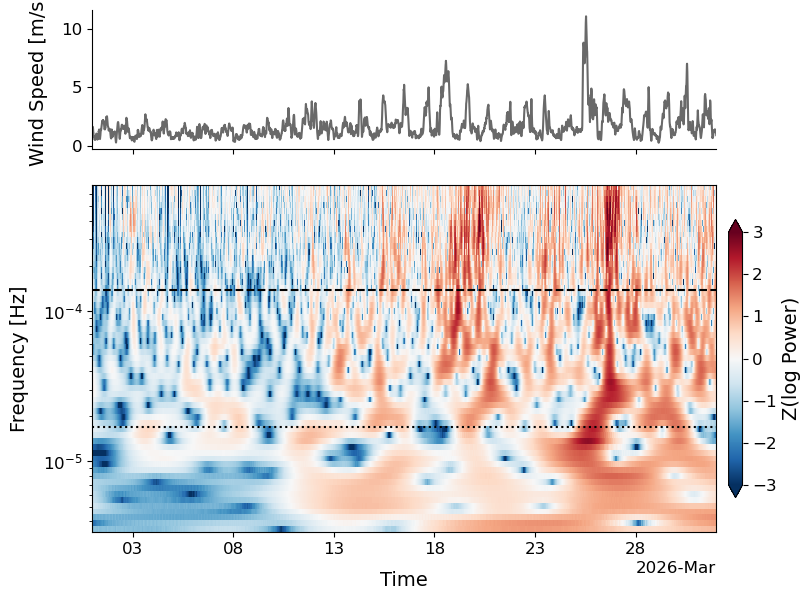

In [101]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, height_ratios=[0.8, 2], layout='constrained')

# wind
sns.lineplot(x=ws_ra.time, y=ws_ra, color='dimgray', ax=ax[0])

ax[1].axhline(f_hz, color='black', linestyle=':')
ax[1].axhline(N_hz, color='black', linestyle='--')
im = pows_do_z.plot(cmap='RdBu_r', vmin=-3, vmax=3, cbar_kwargs={'shrink': 0.8, 'pad': 0.02, 'label': 'Z(log Power)'}, ax=ax[1], rasterized=True)
im.colorbar.ax.yaxis.label.set_size(14)
im.colorbar.ax.tick_params(labelsize=12)

ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Wind Speed [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Frequency [Hz]', fontsize=14, labelpad=10)
ax[1].xaxis.get_offset_text().set_fontsize(12)
ax[1].xaxis.set_major_locator(mdates.DayLocator(interval=5))

ax[0].spines[['right', 'top']].set_visible(False)

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)


ax[1].set_yscale('log')
ax[1].set_xlim(pd.to_datetime(t_start), pd.to_datetime(t_end))

fig.get_layout_engine().set(h_pad=0.1, hspace=0.1)
plt.savefig('../gallery/aphys/2026_08_05/zlogpow_do.svg', bbox_inches='tight')
plt.show()

### Modal Analysis

Compare vertical mode seiche periods to spectral analysis of horizontal velocities.

In [3]:
L = bathy.ysc.max().item() - bathy.ysc.min().item()
nmodes = 3
window_hr = 24 * 30
twfreq = '3D'

#### Summer 2024

In [83]:
date = '2024-07-18'
loc = 'LZC'
sensor = 'adcp'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)
xsc, ysc = mreader.get_swiss_coords(oom=False)

datasets = []
for _, row in di_sel.iterrows():
    reader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = reader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    datasets.append(ds)
ds_adcp = mreader.create_adcp_chain(datasets)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:266: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [66]:
di_sel = di_ctd[di_ctd['date'].between('2024-04-26', '2024-07-18')]

N2_data_s = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    reader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = reader.load()

    if ds.depth.max() > 150:
        rho = ds['rho']
        depth = ds['depth']
        rho = dsi.signal.rolling_average_z(rho, 'mean', 1)
        rho = dsi.signal.order_profile(rho, False, True)
        N2 = dsi.efd.brunt_vaisala_frequency(rho)
        N2 = dsi.signal.binned_average_z(N2, 'median', 1)

        df = N2.to_dataframe().reset_index()
        df[['date', 'time']] = p.date, p.time
        N2_data_s.append(df)

N2_data_s = pd.concat(N2_data_s, ignore_index=True)

  0%|          | 0/64 [00:00<?, ?it/s]

In [67]:
N2_s_mu = xr.DataArray(N2_data_s.groupby('depth')['N2'].mean())
N2_s_med = xr.DataArray(N2_data_s.groupby('depth')['N2'].median())

N2_data_s.groupby(['date', 'time']).ngroups

34

In [96]:
# vertical modes
ev, U, W = dsi.lakes.vertical_modes(N2_s_med, nmodes, method='kundu')

# seiche period
n = 1    # horizontal mode number
c = 1 / np.sqrt(ev)
speriod = (2 * L) / (n * c)
period_s = speriod / 3600
period_s

<xarray.DataArray 'eigenvalue' (mode: 3)> Size: 24B
array([ 32.15949021,  62.35999605, 107.30177367])
Coordinates:
  * mode     (mode) int64 24B 1 2 3

In [84]:
# power spectrum
psd_s = dsi.signal.psd_welch_z(ds_adcp.vel.sel(dir='N'), window_hr, t_windows=True, twfreq=twfreq, pandas=True)

#### Winter 2025

In [81]:
date = '2025-04-24'
loc = 'LZC'
sensor = 'adcp'
di_sel = di_m[(di_m['date'] == date) & (di_m['location'] == loc) & (di_m['sensor'] == sensor)]
mreader = ewg.mooring_reader.MooringReader(lake, pd.to_datetime(date), loc)
xsc, ysc = mreader.get_swiss_coords(oom=False)

datasets = []
for _, row in di_sel.iterrows():
    reader = ewg.adcp_reader.ADCPReader(row.lake, row.date, row.location, row.serial_id)
    ds = reader.load()
    ds = dsi.signal.valid_depths(ds, 0.5)
    ds['depth'] = ds['depth'].round(0)
    datasets.append(ds)
ds_adcp = mreader.create_adcp_chain(datasets, drop=np.array([156]))

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:266: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_adcp = xr.concat(all_adcp_aligned, dim='depth')


In [74]:
di_sel = di_ctd[di_ctd['date'].between('2025-01-16', '2025-04-23')]

N2_data_w = []
for _, p in tqdm(di_sel.iterrows(), total=len(di_sel)):
    reader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = reader.load()

    if ds.depth.max() > 150:
        rho = ds['rho']
        depth = ds['depth']
        rho = dsi.signal.rolling_average_z(rho, 'mean', 1)
        rho = dsi.signal.order_profile(rho, False, True)
        N2 = dsi.efd.brunt_vaisala_frequency(rho)
        N2 = dsi.signal.binned_average_z(N2, 'median', 1)

        df = N2.to_dataframe().reset_index()
        df[['date', 'time']] = p.date, p.time
        N2_data_w.append(df)

N2_data_w = pd.concat(N2_data_w, ignore_index=True)

  0%|          | 0/58 [00:00<?, ?it/s]

In [75]:
N2_w_mu = xr.DataArray(N2_data_w.groupby('depth')['N2'].mean())
N2_w_med = xr.DataArray(N2_data_w.groupby('depth')['N2'].median())

N2_data_w.groupby(['date', 'time']).ngroups

26

In [97]:
# vertical modes
ev, U, W = dsi.lakes.vertical_modes(N2_w_med, nmodes, method='kundu')

# seiche period
n = 1    # horizontal mode number
c = 1 / np.sqrt(ev)
speriod = (2 * L) / (n * c)
period_w = speriod / 3600
period_w

<xarray.DataArray 'eigenvalue' (mode: 3)> Size: 24B
array([108.24074555, 289.79468354, 446.05062837])
Coordinates:
  * mode     (mode) int64 24B 1 2 3

In [82]:
# power spectrum
psd_w = dsi.signal.psd_welch_z(ds_adcp.vel.sel(dir='N'), window_hr, t_windows=True, twfreq=twfreq, pandas=True)

In [ ]:
fig, ax = plt.subplots(figsize=(4, 6))

sns.lineplot(x=N2_s_mu, y=N2_s_mu.depth, orient='y', ax=ax, label='Mean')
sns.lineplot(x=N2_s_med, y=N2_s_med.depth, orient='y', ax=ax, label='Median')

ax.invert_yaxis()
ax.set_xscale('log')

plt.show()

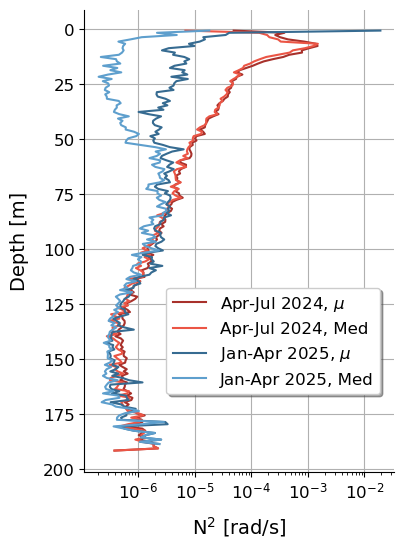

In [115]:
fig, ax = plt.subplots(figsize=(4, 6))
palette_s = sns.color_palette('Reds_d', n_colors=2)
palette_w = sns.color_palette('Blues_d', n_colors=2)


# summer 2024
sns.lineplot(x=N2_s_mu, y=N2_s_mu.depth, orient='y', color=palette_s[1], label=r'Apr-Jul 2024, $\mu$')
sns.lineplot(x=N2_s_med, y=N2_s_med.depth, orient='y', color=palette_s[0], label='Apr-Jul 2024, Med')

# winter 2025
sns.lineplot(x=N2_w_mu, y=N2_w_mu.depth, orient='y', color=palette_w[1], label=r'Jan-Apr 2025, $\mu$')
sns.lineplot(x=N2_w_med, y=N2_w_med.depth, orient='y', color=palette_w[0], label='Jan-Apr 2025, Med')

ax.set_xlabel('N$^2$ [rad/s]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.invert_yaxis()
ax.set_xscale('log')

ax.legend(fontsize=12, ncols=1, shadow=True, loc='lower right', bbox_to_anchor=(0.98, 0.15))

plt.savefig('../gallery/aphys/2026_08_05/modal_N2.svg', bbox_inches='tight')
plt.show()

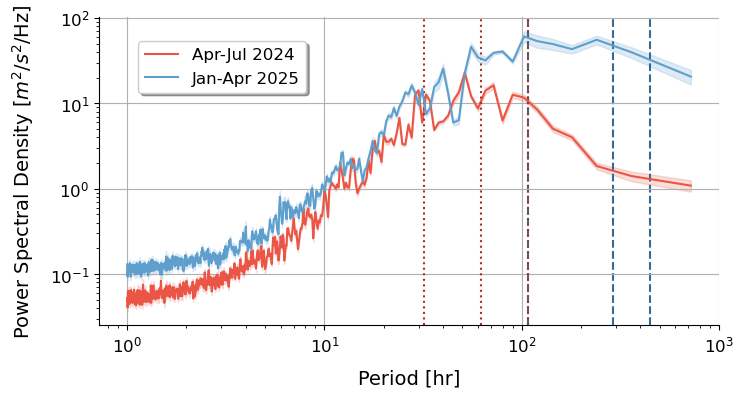

In [114]:
fig, ax = plt.subplots(figsize=(8, 4))
palette_s = sns.color_palette('Reds_d', n_colors=2)
palette_w = sns.color_palette('Blues_d', n_colors=2)

# summer 2024
sns.lineplot(psd_s.query("period > 1"), x='period', y='power_spectral_density', color=palette_s[0], errorbar=('se', 1), ax=ax, label='Apr-Jul 2024')
for T in period_s.values:
    ax.axvline(T, color=palette_s[1], linestyle=':', zorder=2)

# winter 2025
sns.lineplot(psd_w.query("period > 1"), x='period', y='power_spectral_density', color=palette_w[0], errorbar=('se', 1), ax=ax, label='Jan-Apr 2025')
for T in period_w.values:
    ax.axvline(T, color=palette_w[1], linestyle='--', zorder=1)

ax.set_xlabel('Period [hr]', fontsize=14, labelpad=10)
ax.set_ylabel('Power Spectral Density [$m^2$/$s^2$/Hz]', fontsize=14, labelpad=10)
ax.tick_params(axis='both', labelsize=12)

ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(fontsize=12, ncols=1, shadow=True, loc='upper left', bbox_to_anchor=(0.05, 0.95))

plt.savefig('../gallery/aphys/2026_08_05/modal_psd.svg', bbox_inches='tight')
plt.show()